In [29]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [30]:
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [31]:
original_data_path = os.path.join(path, "PetImages")
print("Original folders:", os.listdir(original_data_path))

Original folders: ['Dog', 'Cat']


In [ ]:
clean_base_path = "/kaggle/working/clean_data"

os.makedirs(clean_base_path, exist_ok=True)
os.makedirs(os.path.join(clean_base_path, "Cat"), exist_ok=True)
os.makedirs(os.path.join(clean_base_path, "Dog"), exist_ok=True)

for folder in ["Cat", "Dog"]:
    source_folder = os.path.join(original_data_path, folder)
    target_folder = os.path.join(clean_base_path, folder)

    for file in os.listdir(source_folder):
        file_path = os.path.join(source_folder, file)

        if not file.lower().endswith(".jpg"):
            continue

        try:
            img = Image.open(file_path)
            img = img.convert("RGB")   
            img.save(os.path.join(target_folder, file), "JPEG")
        except:
            pass

print("Clean RGB dataset created successfully.")
print("Cat images:", len(os.listdir(os.path.join(clean_base_path, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(clean_base_path, "Dog"))))

Clean RGB dataset created successfully.
Cat images: 12499
Dog images: 12499


In [48]:
img_size = (128, 128)
batch_size = 32

train_data = image_dataset_from_directory(
    clean_base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode="binary"
)

val_data = image_dataset_from_directory(
    clean_base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode="binary"
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [49]:
class_names = train_data.class_names
print(class_names)

['Cat', 'Dog']


In [50]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

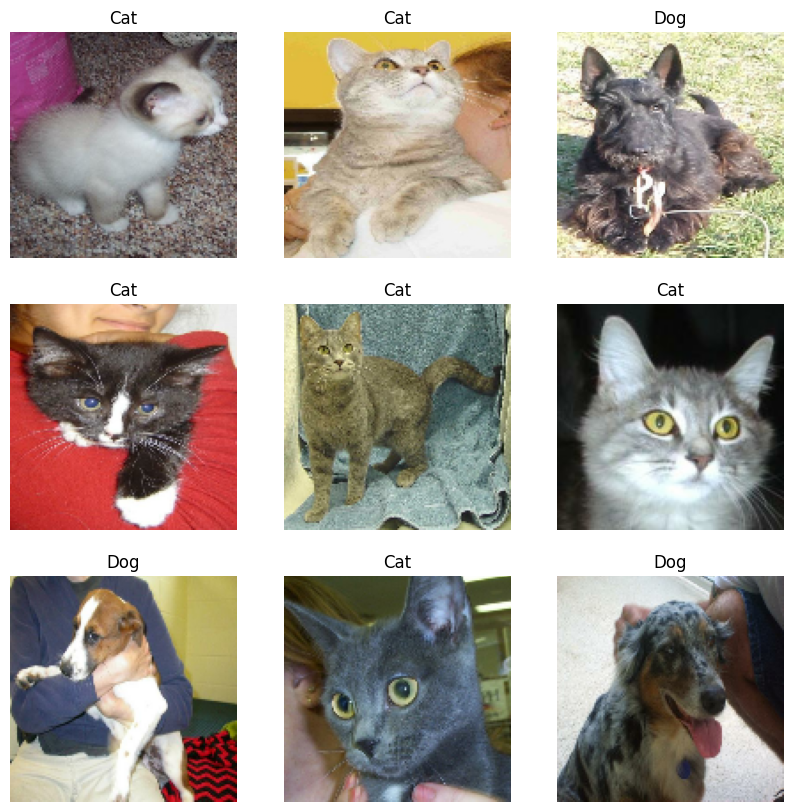

In [51]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")

plt.show()

In [53]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [54]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5984 - loss: 0.6667 - val_accuracy: 0.7664 - val_loss: 0.4951
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7525 - loss: 0.5110 - val_accuracy: 0.7824 - val_loss: 0.4514
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.8067 - loss: 0.4198 - val_accuracy: 0.8192 - val_loss: 0.4008
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8467 - loss: 0.3500 - val_accuracy: 0.8282 - val_loss: 0.3898
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.8797 - loss: 0.2825 - val_accuracy: 0.8414 - val_loss: 0.3806
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9114 - loss: 0.2131 - val_accuracy: 0.8366 - val_loss: 0.4503
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9362 - loss: 0.1592 - val_accuracy: 0.8290 - val_loss: 0.5126
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9526 - loss: 0.1196 - 

In [58]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8489 - loss: 0.3760
Validation Loss: 0.3806362450122833
Validation Accuracy: 0.8413682579994202


In [59]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred).astype(int)

In [60]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8513295729250604
Recall: 0.8328734726054395
F1-score: 0.8420003984857541


In [61]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         Cat       0.83      0.85      0.84      2462
         Dog       0.85      0.83      0.84      2537

    accuracy                           0.84      4999
   macro avg       0.84      0.84      0.84      4999
weighted avg       0.84      0.84      0.84      4999



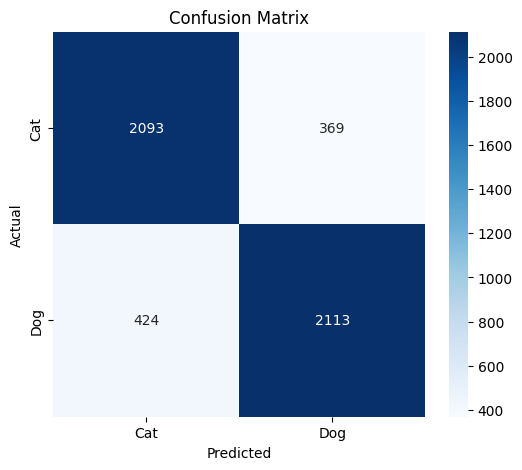

In [62]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

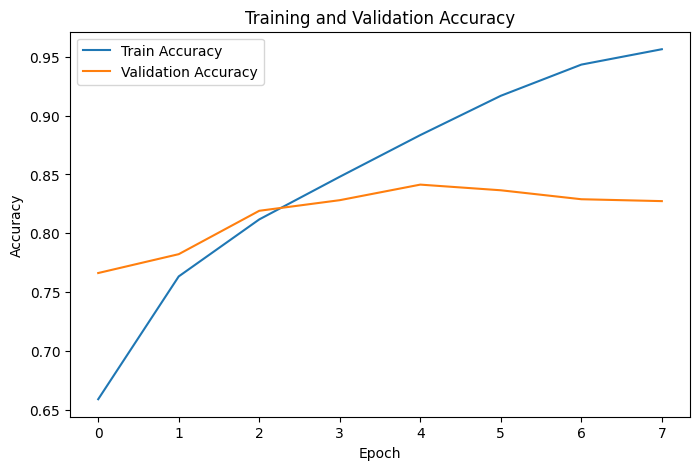

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

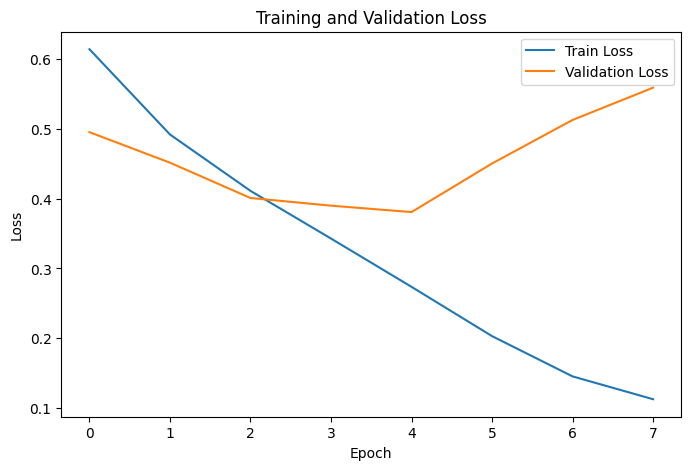

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()